# Online Retail Dataset Analysis

Name: Veronica james Okuba

Dataset: Online Retail Dataset (Kaggle)

Tools Used:
-Python
-Pandas
-Numpy
-Matplotlib
-seaborn
-Google colab


In [ ]:
pip install pandas numpy matplotlib seaborn

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltimport
import seaborn as sns

Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving OnlineRetail.csv to OnlineRetail.csv


Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')



Task 1: Dataset Understanding

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Dataset Shape

In [ ]:
df.shape

(541909, 8)

Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Numerical Features

In [ ]:
numerical=df.select_dtypes(include=['int64','float64']).columns
numerical

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')

Categorical Features

In [ ]:
categorical=df.select_dtypes(include=['object']).columns
categorical

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')

## Dataset Description

The dataset contains online retail transactions including product details, quantities sold,prices, customer IDs,invoice dates and customer countries.


Task 2: Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df[['InvoiceNo','StockCode']].duplicated().sum()

np.int64(10684)

Missing Values

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
(df.isnull().sum()/len(df))*100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


Handle Missing Values

In [ ]:
df=df.dropna(subset=['Description'])



In [ ]:
df.loc[:, 'CustomerID'] = df['CustomerID'].fillna("UNKNOWN")

Duplicates

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df=df.drop_duplicates()

Standardization

In [ ]:
df.columns=df.columns.str.lower()

In [ ]:
df['country']=df['country'].str.upper()

In [ ]:
df['invoicedate']=pd.to_datetime(df['invoicedate'])

Validation

In [ ]:
df[df['quantity'] < 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,month


In [ ]:
df[df['unitprice'] <= 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,month


In [ ]:
df['quantity'].describe()

,quantity
count,535187.000000
mean,9.671593
std,219.059056
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [ ]:
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]

In [ ]:
summary = pd.DataFrame({
    "Issue Found": [
        "Missing Description",
        "Missing CustomerID",
        "Duplicates",
        "Invalid Quantity/Price",
        "Standardization"
    ],
    "Action Taken": [
        "Removed rows",
        "Filled with UNKNOWN",
        "Removed duplicates",
        "Filtered out invalid values",
        "Lowercase columns, uppercase country, datetime conversion"
    ]
})

summary

,Issue Found,Action Taken
0,Missing Description,Removed rows
1,Missing CustomerID,Filled with UNKNOWN
2,Duplicates,Removed duplicates
3,Invalid Quantity/Price,Filtered out invalid values
4,Standardization,"Lowercase columns, uppercase country, datetime..."


## Task 3: Exploratory Data Analysis

In [ ]:
df.describe()

,quantity,invoicedate,unitprice
count,524878.000000,524878,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573
min,1.000000,2010-12-01 08:26:00,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000
50%,4.000000,2011-07-20 11:22:00,2.080000
75%,11.000000,2011-10-19 11:41:00,4.130000
max,80995.000000,2011-12-09 12:50:00,13541.330000
std,156.280031,NaN,36.093028


In [ ]:
df['quantity'].mean()
df['quantity'].median()
df['quantity'].min()
df['quantity'].max()
df['quantity'].std()


156.28003072343193

In [ ]:
df['unitprice'].mean()
df['unitprice'].median()
df['unitprice'].min()
df['unitprice'].max()
df['unitprice'].std()

36.093027531937864

In [ ]:
df[['quantity', 'unitprice']].mean()

,0
quantity,10.616600
unitprice,3.922573


In [ ]:
df[['quantity', 'unitprice']].median()

,0
quantity,4.00
unitprice,2.08


In [ ]:
df[['quantity', 'unitprice']].min()
df[['quantity', 'unitprice']].max()

,0
quantity,80995.00
unitprice,13541.33


In [ ]:
df[['quantity', 'unitprice']].std()

,0
quantity,156.280031
unitprice,36.093028


Top Products

In [ ]:
df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


Revenue column

In [ ]:
df['revenue'] = df['quantity'] * df['unitprice']

In [ ]:
df['month'] = df['invoicedate'].dt.to_period('M')

df.groupby('month')['revenue'].sum()

/tmp/ipykernel_996/988502624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['invoicedate'].dt.to_period('M')


,revenue
month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [ ]:
df['description'].value_counts().head(10)

,count
description,
WHITE HANGING HEART T-LIGHT HOLDER,2311
JUMBO BAG RED RETROSPOT,2109
REGENCY CAKESTAND 3 TIER,2007
PARTY BUNTING,1699
LUNCH BAG RED RETROSPOT,1581
ASSORTED COLOUR BIRD ORNAMENT,1476
SET OF 3 CAKE TINS PANTRY DESIGN,1392
PACK OF 72 RETROSPOT CAKE CASES,1352
LUNCH BAG BLACK SKULL.,1301


In [ ]:
df.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)

,revenue
customerid,
UNKNOWN,1754901.91
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

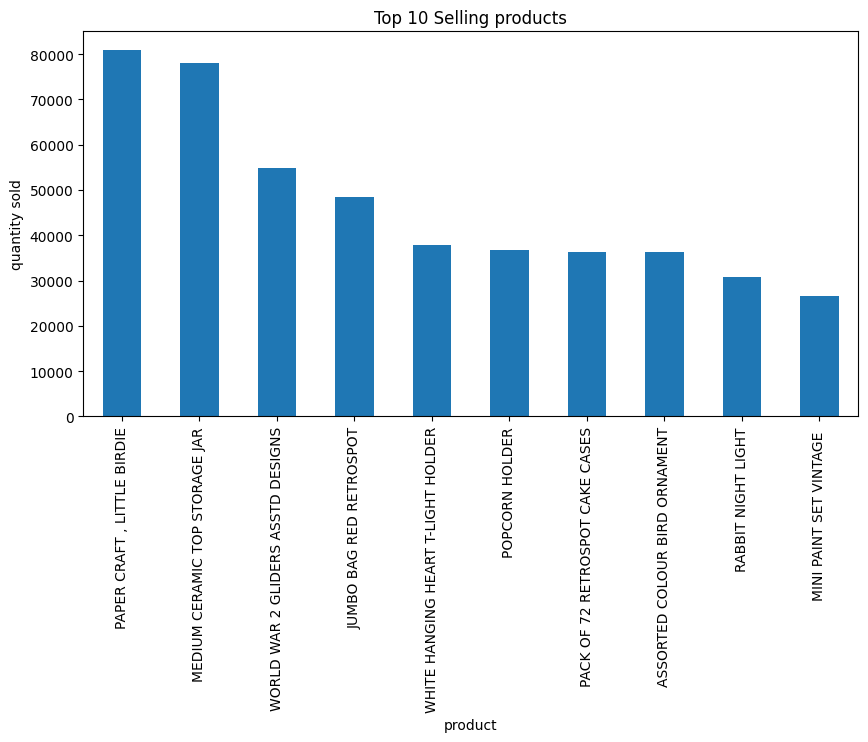

In [ ]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind='bar')
plt.title('Top 10 Selling products')
plt.xlabel('product')
plt.ylabel('quantity sold')
plt.xticks(rotation=90)
plt.show()

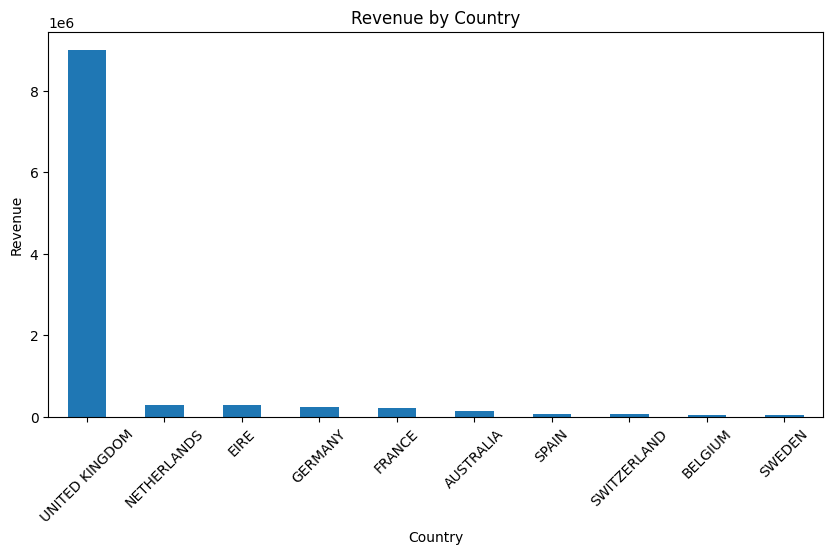

In [ ]:
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
country_revenue.plot(kind='bar')
plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

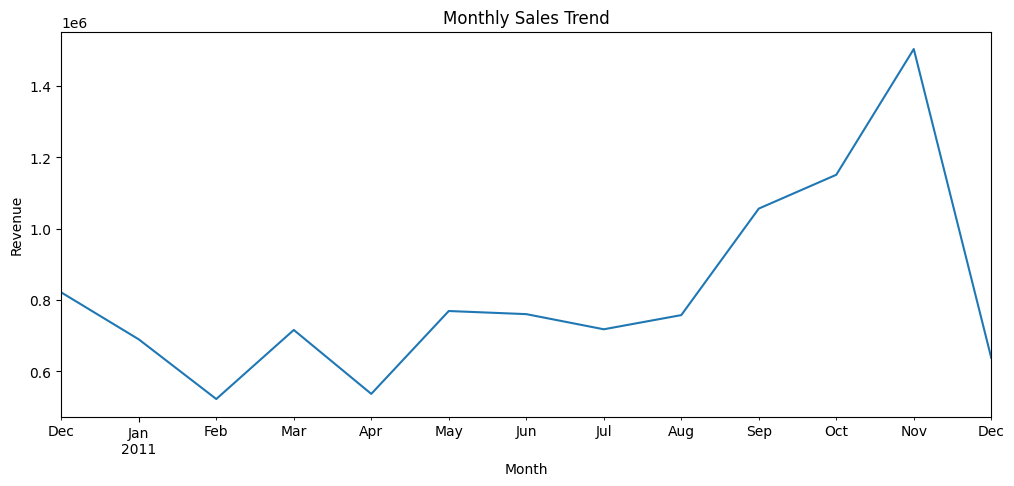

In [ ]:
monthly_revenue = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

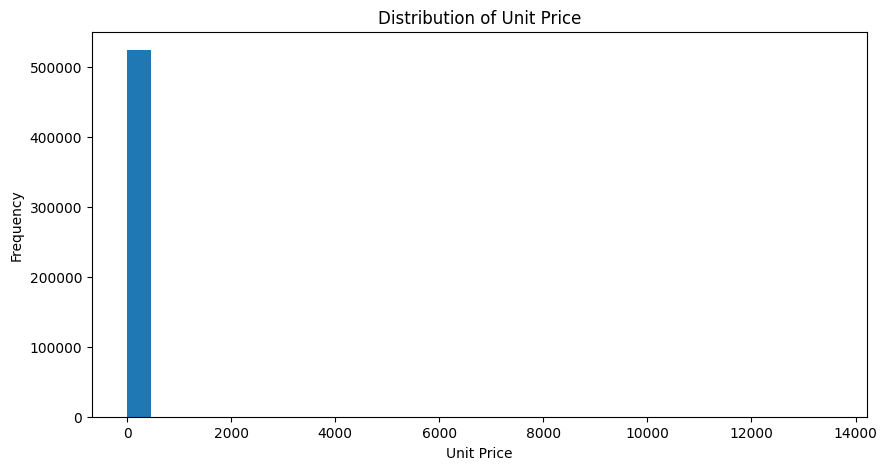

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df['unitprice'],bins=30)
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.show()

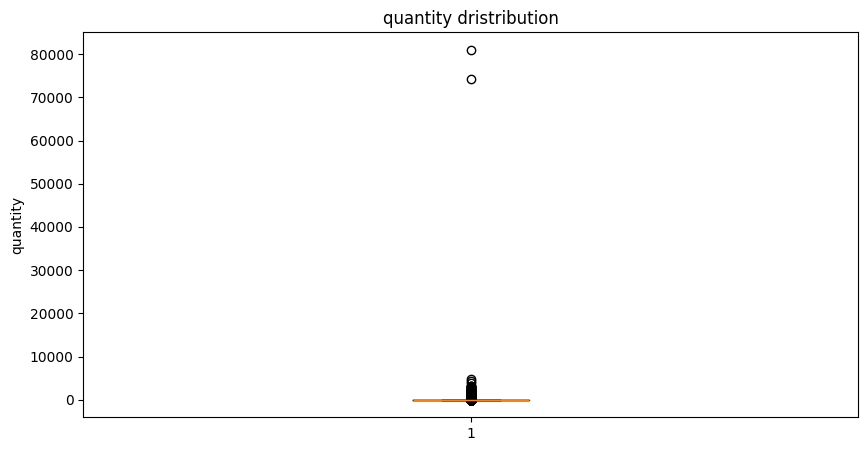

In [ ]:
plt.figure(figsize=(10,5))
plt.boxplot(df['quantity'])
plt.title('quantity dristribution')
plt.ylabel('quantity')
plt.show()

## Task 5: Insights

1. A small number of products account for most sales volumes.

2. The United Kingdom generates the highest revenue.

3. Sales fluctuate across months, showing seasonal patterns.

4. Most products are sold at relatively low prices.

5. Some transactions involve unusually large quantities, indicating bulk purchases.

In [ ]:
df.to_csv('cleaned_online_retail.csv', index=False)

print("cleaned dataset saved as cleaned_online_retail.csv")

cleaned dataset saved as cleaned_online_retail.csv


In [ ]:
from google.colab import files

files.download('cleaned_online_retail.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>